# GPT Notebook

This notebook contains the standalone GPT pretraining path. 

`LayerNormalization`, `Linear`, and `GLU` are custom functions not from torch.nn

`MultiHeadAttention` computes self attention with optional causal and padding masks. 

`TransformerBlock` combines attention, normalization, and the feed forward network. 

`ConfigParametersLLM` and `OptimParameters` hold model and optimizer settings. 

`PreTrainTextDataset` creates next token prediction windows from the Tiny Shakespeare corpus. 

`load_text_tokens` tokenizes the text corpus, 

`build_gpt_dataloader` wraps it in a dataloader, 

`evaluate_gpt_loss` computes mean loss over a loader. 

`get_lr_scheduler`  learning rate schedule for the optimizer

`GPT` builds the decoder only transformer with token embeddings, position embeddings, transformer blocks, and the output projection. The remaining cells set up training, run optimization, save the checkpoint, and plot the loss curve.

In [1]:
%load_ext autoreload                                                                                                                                                                  
%autoreload 2 

%reload_ext autoreload
  
import os
import sys
sys.path.insert(0, '..')
sys.path.insert(0, '../src')
sys.path.insert(0, '../src/model')

import matplotlib.pyplot as plt
import torch
from typing import Any

from src.model.attention import MultiHeadAttention
from src.model.gpt import (
    GPT,
    TransformerBlock,
    LayerNormalization,
    Linear,
    GLU,
)
from src.configs import ConfigParametersLLM, OptimParameters
from src.text_datasets import PreTrainTextDataset, build_gpt_dataloader, load_text_tokens
from src.train_helper import evaluate_gpt_loss, get_lr_scheduler

/home/pensativo/code/vision-ai-guide/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Training Setup

In [3]:
#set LLM config hyperparameters
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

llm_config = {
    "vocab_size": 50257, #vocab size of the GPT2 tokenizer on HF
    "num_blocks": 4, #number of transformer blocks
    "batch_size": 32, #batch size
    "device": device, #device
    "chunk_size": 512, #chunk size
    "model_dim": 768, #model dimension
    "num_heads": 4, #number of heads
    "max_seq_length": 512, #max sequence length
    "output_dir": "../outputs/llm_rope", #output directory
    "data_path": "../data/wikitext-103-raw/train.txt", #data path
    "pos_emb_type": "rope" #position embedding type
}

#set optimizer hyperparameters
optim_config = {
    "lr": 4e-4, #learning rate
    "betas": (0.9, 0.95), #betas
    "eps": 1e-8, #epsilon
    "scheduler": True, #use a learning rate scheduler
    "compile": True, #compile the model
    "autocast": True, #autocast
    "autocast_dtype": torch.bfloat16, #autocast dtype
    "min_lr": 1e-5, #minimum learning rate
    "warmup_steps": 200, #warmup steps
    "max_steps": 15000 #max steps
}

#check if output directory exists and create it if it doesn't
output_dir = llm_config["output_dir"]

if not os.path.exists(output_dir):
    os.makedirs(output_dir, exist_ok=True)

#check if data path exists and raise an error if it doesn't
data_path = llm_config["data_path"]
if not os.path.exists(data_path):
    raise FileNotFoundError(f"Data path {data_path} does not exist")

In [4]:
tokenizer, train_data = load_text_tokens(data_path)

Token indices sequence length is longer than the specified maximum sequence length for this model (117920140 > 1024). Running this sequence through the model will result in indexing errors


In [5]:
llm_config_obj = ConfigParametersLLM.from_dict(llm_config)
train_loader = build_gpt_dataloader(train_data, llm_config_obj, shuffle=True)
len(train_loader)

3684989

In [6]:
opt_cfg = OptimParameters.from_dict(optim_config)

model = GPT(llm_config_obj).to(device)

if opt_cfg.compile is not None:
    model = torch.compile(model)  

optimizer = torch.optim.AdamW(
    model.parameters(),
    opt_cfg.lr,
    betas=opt_cfg.betas,
    eps=opt_cfg.eps,
)

if opt_cfg.scheduler is not None:
    scheduler = get_lr_scheduler(optimizer, opt_cfg)

## Training Loop

In [7]:
def save_checkpoint(
    ckpt_path: str, 
    step: int, 
    model: torch.nn.Module, 
    optimizer: torch.optim.Optimizer, 
    scheduler: torch.optim.lr_scheduler.LRScheduler, 
    train_loss: list,
    opt_cfg: OptimParameters)->None:

    """Save the model, optimizer, and scheduler state dictionaries to a checkpoint file.
    Args:
        ckpt_path: str, path to save the checkpoint file
        step: int, current step number
        model: torch.nn.Module, model to save
        optimizer: torch.optim.Optimizer, optimizer to save
        scheduler: torch.optim.lr_scheduler.LRScheduler, scheduler to save
        train_loss: list, training loss values
    """
    if opt_cfg.compile is not None:
        raw_model = getattr(model, "_orig_mod", model) 

    payload = {    
        "step": step,
        "model": raw_model.state_dict(),
        "train_loss": train_loss,
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict() if scheduler is not None else None
    }
    tmp = ckpt_path + ".tmp"
    torch.save(payload, tmp)                                                                                                                                                          
    os.replace(tmp, ckpt_path)

In [8]:
def train_gpt(
    model: torch.nn.Module,
    train_loader: torch.utils.data.DataLoader,
    opt_cfg: OptimParameters,
    output_dir: str,
    device: torch.device
):

    model.train()
    step = 0
    max_steps = opt_cfg.max_steps 
    train_loss = []

    os.makedirs(output_dir, exist_ok=True)

    print_every = max_steps // 20
    save_every = max_steps // 10


    while step < max_steps:
        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            #autocast to bf16 for faster training
            if opt_cfg.autocast is not None:
                with torch.autocast(device_type="cuda", dtype=opt_cfg.autocast_dtype):     
                    logits, loss = model(x, y) 

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()  
            if opt_cfg.scheduler:                                                                                                                                                          
                scheduler.step() 

            train_loss.append(loss.item())
            step += 1

            if step % print_every == 0:
                print(f"Step {step} | Loss {loss.item():.4f}")
        
            if step % save_every == 0:
                ckpt_path = os.path.join(output_dir, f"llm_wikitext_step{step:07d}.pt")

                save_checkpoint(
                    ckpt_path=os.path.join(output_dir, f"llm_wikitext_step{step:07d}.pt"),
                    step=step,
                    model=model,
                    optimizer=optimizer,
                    scheduler=scheduler,
                    train_loss=train_loss,
                    opt_cfg=opt_cfg
                )
                print(f"Checkpoint saved at step {step}")

            if step >= max_steps:
                break
                                                                                                                                         
    ckpt_path = os.path.join(output_dir, "llm_wikitext_rope_final.pt")
    torch.save(
        {"step": step, "model": model.state_dict(), "train_loss": train_loss},
        ckpt_path,
    )
    return train_loss

## Loss Plot

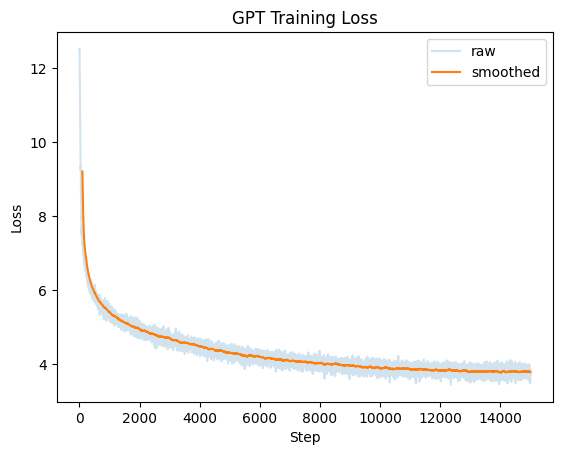

In [13]:
window = 100
smoothed = [
    sum(train_loss[i : i + window]) / window
    for i in range(len(train_loss) - window + 1)
]

plt.plot(train_loss, alpha=0.2, label="raw")
plt.plot(range(window - 1, len(train_loss)), smoothed, label="smoothed")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("GPT Training Loss")
plt.legend()
plt.show()


In [9]:
## Training with Rope Embeddings
train_loss = train_gpt(model, train_loader, opt_cfg, output_dir, device)

W0427 12:53:52.857000 194786 torch/_inductor/utils.py:1727] [0/0_1] Not enough SMs to use max_autotune_gemm mode


Step 750 | Loss 5.2202
Step 1500 | Loss 4.6623
Checkpoint saved at step 1500
Step 2250 | Loss 4.5087
Step 3000 | Loss 4.4390
Checkpoint saved at step 3000
Step 3750 | Loss 4.0966
Step 4500 | Loss 4.1702
Checkpoint saved at step 4500
Step 5250 | Loss 4.1890
Step 6000 | Loss 3.9870
Checkpoint saved at step 6000
Step 6750 | Loss 3.8814
Step 7500 | Loss 3.7956
Checkpoint saved at step 7500
Step 8250 | Loss 3.7351
Step 9000 | Loss 3.7047
Checkpoint saved at step 9000
Step 9750 | Loss 3.7666
Step 10500 | Loss 3.5887
Checkpoint saved at step 10500
Step 11250 | Loss 3.5999
Step 12000 | Loss 3.6215
Checkpoint saved at step 12000
Step 12750 | Loss 3.7261
Step 13500 | Loss 3.6452
Checkpoint saved at step 13500
Step 14250 | Loss 3.5417
Step 15000 | Loss 3.6128
Checkpoint saved at step 15000


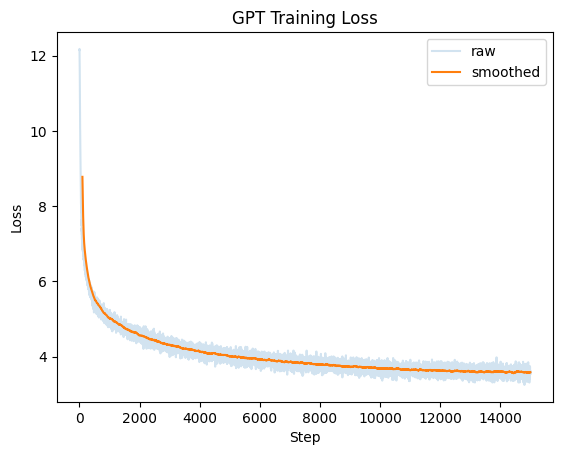

In [10]:
window = 100
smoothed = [
    sum(train_loss[i : i + window]) / window
    for i in range(len(train_loss) - window + 1)
]

plt.plot(train_loss, alpha=0.2, label="raw")
plt.plot(range(window - 1, len(train_loss)), smoothed, label="smoothed")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("GPT Training Loss")
plt.legend()
plt.show()